<a href="https://colab.research.google.com/github/NajiaB/The-Motif-Hunt/blob/main/motif_hunt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧬🧬🧬 The Motif Hunt
## A secret is hiding in the DNA...
---

In this tutorial, we'll use deep learning to solve a real problem in biology: finding the secret pattern that makes a protein stick to DNA.

Certain proteins called transcription factors act like switches: they grab onto specific spots in your DNA and turn genes on or off. The spot they grab onto always has a short repeated pattern called a **[motif](https://open.oregonstate.education/appliedbioinformatics/chapter/chapter-2-sequence-motifs/)**.

The catch? We don't know what the motif looks like. All we have is a list of DNA sequences and a simple yes/no answer for each one: did the protein bind here or not?

Our job is to train a **neural network** to learn the difference between sequences the protein likes and sequences it ignores, and then figure out why. What pattern did it actually learn?

All we know is that the motif we're looking for is composed of exactly 12 nucleotides.

That's the mystery we're solving today.

---

| Step | What you'll do |
|------|---------------|
| 1 | Load the data and explore the sequences |
| 2 | See how the AI reads DNA (one-hot encoding) |
| 3 | Watch the AI make predictions |
| 4 | Explore saliency maps (which bases matter most?) |
| 5 | Extract what the AI actually learned => Slido |
| 6 | The motif reveal  |



## Part 0: Setting up our tools

To run this notebook, you may first need to make a copy by choosing **File > Save a Copy in Drive** from the menu bar.

Before starting, please run this cell as we will need these elements later on.

You don't need to understand every line. Just run it and move on!

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

try:
    import logomaker
except ImportError:
    os.system('pip install logomaker -q')
    import logomaker

MOTIF_LEN   = 12
BASES       = ['A', 'C', 'G', 'T']
base2idx    = {'A': 0, 'C': 1, 'G': 2, 'T': 3}
LOGO_COLORS = {'A': 'red', 'C': 'blue', 'G': 'green', 'T': 'orange'}

def plot_logo(pfm, title=''):
    df      = pd.DataFrame(pfm.astype(float), columns=BASES)
    info_df = logomaker.transform_matrix(df, from_type='probability', to_type='information')
    fig, ax = plt.subplots(figsize=(12, 3))
    logomaker.Logo(info_df, ax=ax, color_scheme=LOGO_COLORS)
    ax.set_ylabel('Bits'); ax.set_ylim(0, 2.2)
    ax.set_title(title, fontweight='bold')
    ax.set_xticks(range(len(pfm)))
    ax.set_xticklabels([f'pos {i+1}' for i in range(len(pfm))])
    plt.tight_layout()
    plt.show()


## 🔬 Part 1 - The Dataset

Here's what we're working with:

- 2000 DNA sequences.
- Each sequence is labeled 1 (protein bound ✓) or 0 (protein didn't bind ✗)
- The motif is hiding somewhere in the **positive** sequences - but we won't tell you what it is yet ;)

In [2]:
# Let's load the dataset:
import requests

SEQUENCES_URL = 'https://raw.githubusercontent.com/NajiaB/The-Motif-Hunt/main/sequences_with_labels.csv'

df = pd.read_csv(SEQUENCES_URL)

sequences = df['sequence'].tolist()
labels = df['bound'].tolist()

print(f"Loaded {len(sequences)} sequences")
df.head()


Loaded 2000 sequences


,sequence,bound
0,CCGAGGGCTATGGTTTGGAAGTTAGAACCCTGGGGCTTCTCGCGGA...,0
1,GAGTTTATATGGCGCGAGCCTAGTGGTTTTTGTACTTGTTTGTCGC...,0
2,GATCAGTAGGGAAACAAACAGAGGGCCCAGCCACATCTAGCAGGTA...,0
3,GTCCACGACCGAACTCCCACCTTGACCGCAGAGGTACCACCAGAGC...,1
4,GGCGACCGAACTCCAACTAGAACCTGCATAACTGGCCTGGGAGATA...,1


In [3]:
# Can you double-check the sequences are 50 bp long? Use the first sequence.

len(df['sequence'][0])

50

## 🔎 Part 2 - How the AI Reads DNA

Neural networks can't read letters. We convert each base to a row of 0s and 1s:

```
A → [1, 0, 0, 0]
C → [0, 1, 0, 0]
G → [0, 0, 1, 0]
T → [0, 0, 0, 1]
```

A 50-base sequence becomes a **50 × 4 matrix**, just like a tiny black-and-white image. This is what we're feeding to the neural network.

For example, the sequence *AGTGCTGAT* becomes:
```
        A   G   T   G   C   T   G   A   T
   A  [ 1   0   0   0   0   0   0   1   0 ]
   C  [ 0   0   0   0   1   0   0   0   0 ]
   G  [ 0   1   0   1   0   0   1   0   0 ]
   T  [ 0   0   1   0   0   1   0   0   1 ]
```

In [4]:
# Let's one hot encode our sequences!
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

integer_encoder = LabelEncoder()
one_hot_encoder = OneHotEncoder(categories='auto', sparse_output=False)

input_features = []
for sequence in sequences:
    integer_encoded = integer_encoder.fit_transform(list(sequence)).reshape(-1, 1)
    one_hot_encoded = one_hot_encoder.fit_transform(integer_encoded)
    input_features.append(one_hot_encoded)

input_features = np.stack(input_features)

In [5]:
# Example of what it looks like:
np.set_printoptions(threshold=40)
print("Example sequence\n-----------------------")
print('DNA Sequence #1:\n',sequences[0][:3],'...',sequences[0][-3:])  # first and last 5 nulcleotides
print('One hot encoding of Sequence #1:\n',input_features[0].T)

Example sequence
-----------------------
DNA Sequence #1:
 CCG ... ACC
One hot encoding of Sequence #1:
 [[0. 0. 0. ... 1. 0. 0.]
 [1. 1. 0. ... 0. 1. 1.]
 [0. 0. 1. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [6]:
# One-hot encode labels too!!
one_hot_encoder_labels = OneHotEncoder(categories='auto', sparse_output=False)
input_labels = one_hot_encoder_labels.fit_transform(np.array(labels).reshape(-1, 1))

In [7]:
input_labels.T

array([[1., 1., 1., ..., 1., 0., 0.],
       [0., 0., 0., ..., 0., 1., 1.]])

Now that our sequences are ready, we need to split them into two groups:

- **Training set**: the sequences the model will learn from
- **Test set**: sequences we hide from the model and only use at the end to check if it actually learned something

We'll use 75% of the data for training and hold back 25% for testing.


In [8]:
from sklearn.model_selection import train_test_split

train_features, test_features, train_labels, test_labels = train_test_split(
    input_features, input_labels, test_size=0.25, random_state=42)

print(f"Training:   {len(train_features)} sequences")
print(f"Testing:    {len(test_features)} sequences")

Training:   1500 sequences
Testing:    500 sequences


## 🤖 Part 3 - The AI Model

Now comes the fun part. We get to build and train the AI model!!

#### Build the model!

We're going to use a type of neural network called a Convolutional Neural Network (CNN). You can think of it like a magnifying glass sliding along each DNA sequence, looking for a familiar shape.

Of course, the CNN doesn't know what shape to look for yet. It will figure that out during training when it sees plenty of other sequences, and will try to make the link between what's common to all positive sequences (the motif, actually 😜).

We'll build it using **Keras**, a beginner-friendly library that lets us stack layers like building blocks.


| Layer | What it does |
|------|---------------|
| Conv1D | 32 filters slide along the DNA sequence, each one learning to recognize a different 12-base pattern |
| MaxPooling1D | Keeps only the strongest signal from each filter |
| Flatten | Squishes all the filter outputs into one long list so the next layer can read it |
| Dense (16) | A small thinking layer that combines everything the filters found|
| Dense (2) | The final decision: does this sequence bind the protein or not? |



In [9]:
from tensorflow.keras.layers import Conv1D, Dense, MaxPooling1D, Flatten
from tensorflow.keras.models import Sequential

model = Sequential()
model.add(Conv1D(filters=32, kernel_size=12,
                 input_shape=(train_features.shape[1], 4)))
model.add(MaxPooling1D(pool_size=4))
model.add(Flatten())
model.add(Dense(16, activation='relu'))
model.add(Dense(2, activation='softmax'))

model.compile(loss='binary_crossentropy', optimizer='adam',
              metrics=['binary_accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 39, 32)         │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 9, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 288)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,226 (24.32 KB)

 Trainable params: 6,226 (24.32 KB)

 Non-trainable params: 0 (0.00 B)

#### Train the model!

This is where the magic happens. We show the model thousands of labeled sequences,
and it slowly adjusts its filters until it gets good at telling them apart.

Each pass through the full dataset is called an **[epoch](https://www.geeksforgeeks.org/machine-learning/epoch-in-machine-learning/)**.
Watch the loss go down and the accuracy go up -- that's the network learning in real time.

Question: At what epoch does the model seem to stop improving?


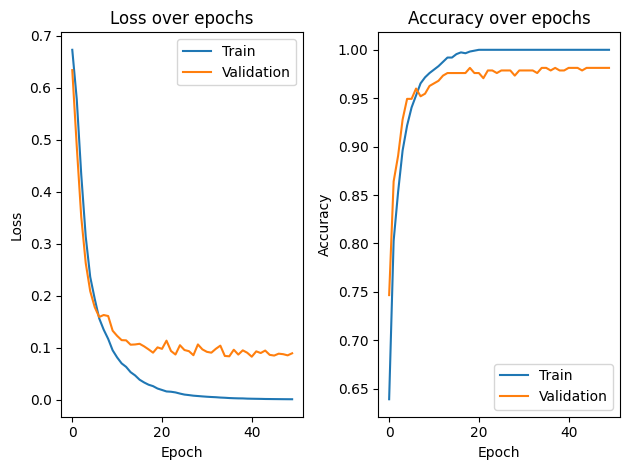

In [10]:
history = model.fit(train_features, train_labels,
                    epochs=50, verbose=0, validation_split=0.25)


fig, axes = plt.subplots(1, 2)

axes[0].plot(history.history['loss'], label='Train')
axes[0].plot(history.history['val_loss'], label='Validation')
axes[0].set_title('Loss over epochs')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history.history['binary_accuracy'], label='Train')
axes[1].plot(history.history['val_binary_accuracy'], label='Validation')
axes[1].set_title('Accuracy over epochs')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()


## Part 4 - Model Evaluation: Did our model actually learn something?

Now that the model is trained, we need to ask: did it actually learn something, or did it just get lucky?

We test this by showing it sequences it has never seen before -- the test set we held back at the beginning. If the model truly learned the pattern, it should do well on new data too. If it only memorized the training data, it'll fall apart here. This problem is called **[overfitting](https://en.wikipedia.org/wiki/Overfitting)**, and it's one of the biggest pitfalls in machine learning.

| | Model says: NO | Model says: YES |
|---|---|---|
| Actually NO | True Negative  | False Positive  |
| Actually YES | False Negative  | True Positive  |

- In your opinion, what should a great model performance look like?



16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Confusion matrix:
 [[255   4]
 [  1 240]]


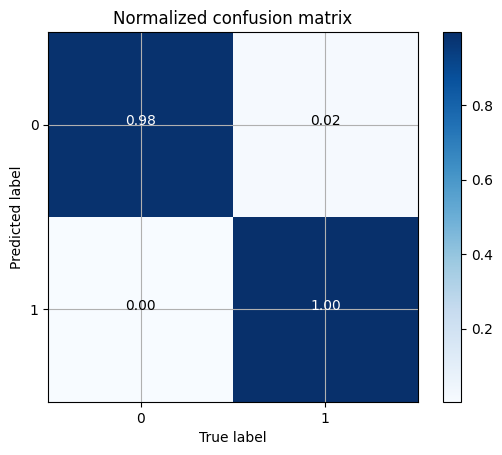

In [11]:
from sklearn.metrics import confusion_matrix
import itertools

predicted_labels = model.predict(np.stack(test_features))
cm = confusion_matrix(np.argmax(test_labels, axis=1),
                      np.argmax(predicted_labels, axis=1))
print('Confusion matrix:\n',cm)

# normalize
cm = cm.astype('float') / cm.sum(axis = 1)[:, np.newaxis]

plt.imshow(cm, cmap=plt.cm.Blues)
plt.title('Normalized confusion matrix')
plt.colorbar()
plt.xlabel('True label')
plt.ylabel('Predicted label')
plt.xticks([0, 1]); plt.yticks([0, 1])
plt.grid('off')
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, format(cm[i, j], '.2f'),
             horizontalalignment='center',
             color='white' if cm[i, j] > 0.5 else 'black')

What do you think about these results?

## 🕵️ Part 5 - What did the model actually learn?

The model is accurate. But *why* does it classify sequences the way it does?
What pattern is it actually looking for to determine whether the protein is BOUND or NOT?

To find out, we use a **saliency map**. The idea is simple:

> *If we slightly change a base at position X, how much does the prediction change?*

A base that changes the prediction a lot = the model is paying close attention to it.** => IMPORTANT FEATURE **

A base that changes nothing = the model doesn't care about it.

This is the AI's highlighter. Let's see what it highlights.


In [12]:
def compute_salient_bases(model, x):
    x_tensor = tf.convert_to_tensor(np.expand_dims(x, axis=0), dtype=tf.float32)
    with tf.GradientTape() as tape:
        tape.watch(x_tensor)
        output = model(x_tensor)
        target = output[0][1]
    gradients = tape.gradient(target, x_tensor)[0].numpy()
    sal = np.clip(np.sum(np.multiply(gradients, x), axis=1), a_min=0, a_max=None)
    return sal


Let's look at a sequence the model is very confident about.  
The bars show how much the model cares about each base.

**Try changing `sequence_index`** to look at different sequences.  You might want to look at positive sequences ;)

Look for positions that light up consistently. Remember, the motif is 12 nucleotides long.

> 💬 **Write down your guess:** what do you think the motif is?

Join our Slido session, and enter your motif guess! : https://www.slido.com/



True label:  Binding
AI confidence:  100.0%


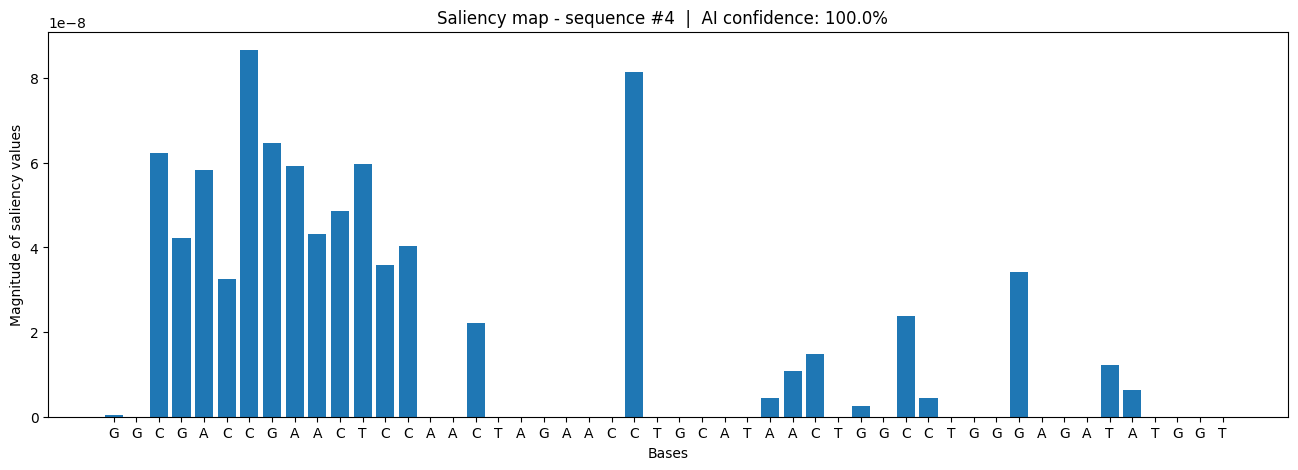

In [13]:
sequence_index = 4  #  You can change this to explore different sequences ;)

sal  = compute_salient_bases(model, input_features[sequence_index])
prob = model.predict(input_features[sequence_index:sequence_index+1], verbose=0)[0][1]

print(f'True label:  {"Binding" if labels[sequence_index] == 1 else "No binding"}')
print(f'AI confidence:  {prob:.1%}')

plt.figure(figsize=[16, 5])
barlist = plt.bar(np.arange(len(sal)), sal)
plt.xlabel('Bases')
plt.ylabel('Magnitude of saliency values')
plt.xticks(np.arange(len(sal)), list(sequences[sequence_index]))
plt.title(f'Saliency map - sequence #{sequence_index}  |  AI confidence: {prob:.1%}  ')

plt.show()

Now, instead of looking at individual sequences, let's look at all the sequences together.

Here's the idea:
- Take every sequence the model is very confident about
- For each one, find the region with the highest saliency
- Extract that 12-base window
- Stack all of them on top of each other

We summarize this with a **[sequence logo](https://en.wikipedia.org/wiki/Sequence_logo)**:
- Each column = one position in the motif
- The **height** of a letter = how often that base appears at that position
- A tall letter means the AI is very sure about that base
- A short letter means it's less certain



Using 992 high-confidence sequences...


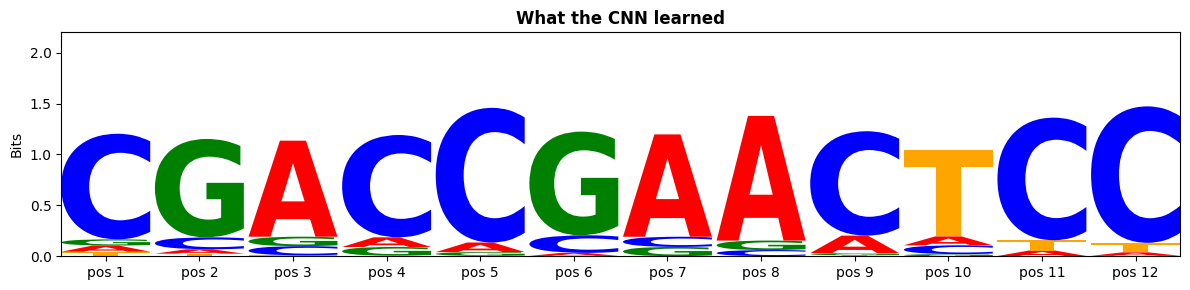

In [14]:
# Find all sequences the model is very confident about
all_probs = model.predict(input_features, verbose=0)[:, 1]
high_conf = np.where(all_probs > 0.9)[0]
print(f'Using {len(high_conf)} high-confidence sequences...')

# For each one, find the region with the highest saliency
pfm = np.zeros((MOTIF_LEN, 4))
for i in high_conf:
    sal        = compute_salient_bases(model, input_features[i])
    best_start = int(np.argmax([sal[j:j+MOTIF_LEN].sum() for j in range(len(sal) - MOTIF_LEN)]))
    for j, base in enumerate(sequences[i][best_start:best_start+MOTIF_LEN]):
        if base in base2idx:
            pfm[j, base2idx[base]] += 1

pfm = pfm / pfm.sum(axis=1, keepdims=True)

# Plot the sequence logo
plot_logo(pfm, title='What the CNN learned')

Was your guess correct? :)

*This notebook is inspired from the paper: Zou, J., Huss, M., Abid, A. et al. A primer on deep learning in genomics. Nat Genet 51, 12–18 (2019).*

